# Clustering and Association Rule Mining Assignment

## Business Understanding

The goal of this assignment is to apply clustering and association rule mining methods to a practical data analysis problem. Clustering is used to group customer locations in order to find suitable hub locations for a drone delivery system. Association rule mining is used to discover relationships between product groups that are often purchased together. The objective is to understand how these methods work and how they can be used to support business decisions.

The objectives of this assignment are:
- to learn to use clustering methods to group similar data points
- to find optimal hub locations based on customer locations
- to compare different clustering approaches
- to use association rule mining to find relationships between product groups

In [153]:
# imports

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

## Data understanding

The assignment is divided into two parts: clustering and association rule mining. We will first analyze the customer locations data and then the product groups data. The customer locations data contains the latitude and longitude of customers, while the product groups data contains information about what type of products customers have purchased.

### Understanding the customer locations data

In [137]:
# Load the customer locations csv file into a pandas DataFrame
customer_locations = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')

customer_locations.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


The customer locations dataset contains raw coordinates of customers. We can easily use this data to find suitable hub locations for a drone delivery system. The goal is to cluster the customer locations and find the optimal hub locations based on the clusters. We will use different clustering methods to find the best solution for this problem.

The dataset columns are:
- client_id: a unique identifier for each customer
- x: the x-coordinate (latitude) of the customer's location
- y: the y-coordinate (longitude) of the customer's location

Lets first view some of the basic statistics of the customer locations dataset to understand the distribution of the data.

In [138]:
# The amount of rows that represent the amount of customer locations
print(f'The amount of customer locations: {len(customer_locations)}')

# The location of the customer location (row) that has the biggest sum of x and y coordinates
max_location = customer_locations.loc[customer_locations[['x', 'y']].sum(axis=1).idxmax()]
print(f'Customer location with the biggest sum of x and y coordinates (x: {max_location["x"]}, y: {max_location["y"]})')

# The location of the customer location (row) that has the smallest sum of x and y coordinates
min_location = customer_locations.loc[customer_locations[['x', 'y']].sum(axis=1).idxmin()]
print(f'Customer location with the smallest sum of x and y coordinates (x: {min_location["x"]}, y: {min_location["y"]})')

# The mean of the x and y coordinates
print(f'Mean of x coordinates: {customer_locations["x"].mean()}')
print(f'Mean of y coordinates: {customer_locations["y"].mean()}')

# The standard deviation of the x and y coordinates
print(f'Standard deviation of x coordinates: {customer_locations["x"].std()}')
print(f'Standard deviation of y coordinates: {customer_locations["y"].std()}')

The amount of customer locations: 5956
Customer location with the biggest sum of x and y coordinates (x: 986.6651132, y: 881.4169899)
Customer location with the smallest sum of x and y coordinates (x: 3.651992525, y: 104.732197)
Mean of x coordinates: 508.82317739158844
Mean of y coordinates: 427.55477153626543
Standard deviation of x coordinates: 271.06146235485505
Standard deviation of y coordinates: 289.04463955089375


There is a total of 5956 locations in the dataset. Both x and y coordinates have quite similar deviation and mean values which suggests that the data is quite evenly distributed.

To visualize the customer locations, we can create a scatter plot of the x and y coordinates. This will help us understand the distribution of the customers and identify any potential clusters.

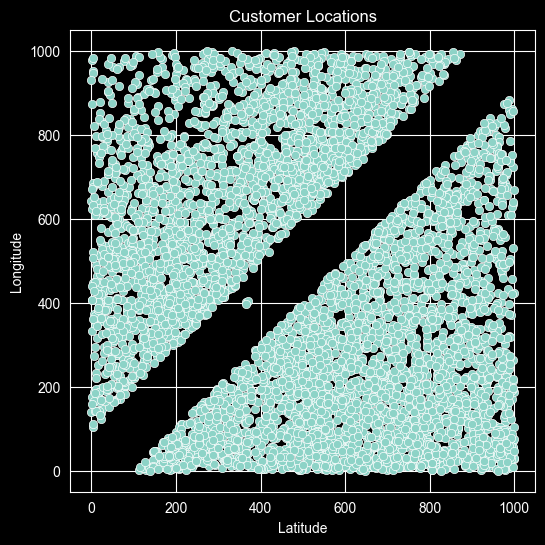

In [139]:
# Scatter plot of customer locations
plt.figure(figsize=(6, 6))
sns.scatterplot(data=customer_locations, x='x', y='y')
plt.title('Customer Locations')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

From the scatter plot we can see that there are two clear clusters of customer locations. In the middle part of the plot, around the x=400 and y=400 area there are few stray locations. Those could be false data points or outliers, but because there are only few of them, we can ignore them for the clustering part.

In [140]:
# Load the product groups csv file into a pandas DataFrame
product_groups = pd.read_csv('datasets/drone_prod_groups.csv', sep=',')

product_groups.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


The product groups dataset contains information about what type of products customers have purchased. Every row in the dataset represents a customer and the columns represent different products. If the products value is 1, it means that the customer has purchased that product, and if the value is 0, it means that the customer has not purchased that product. The goal is to use association rule mining to find relationships between product groups and discover which products are often purchased together.

The dataset columns are:
- ID: a unique identifier for each customer
- Prod1 - Prod20: binary columns indicating whether the customer has purchased a specific product (1) or not (0)

The dataframe itself is already visualizing the data quite well, but we can also create a heatmap to visualize the relationships between the products. This will help us understand which products are often purchased together and identify any potential associations.

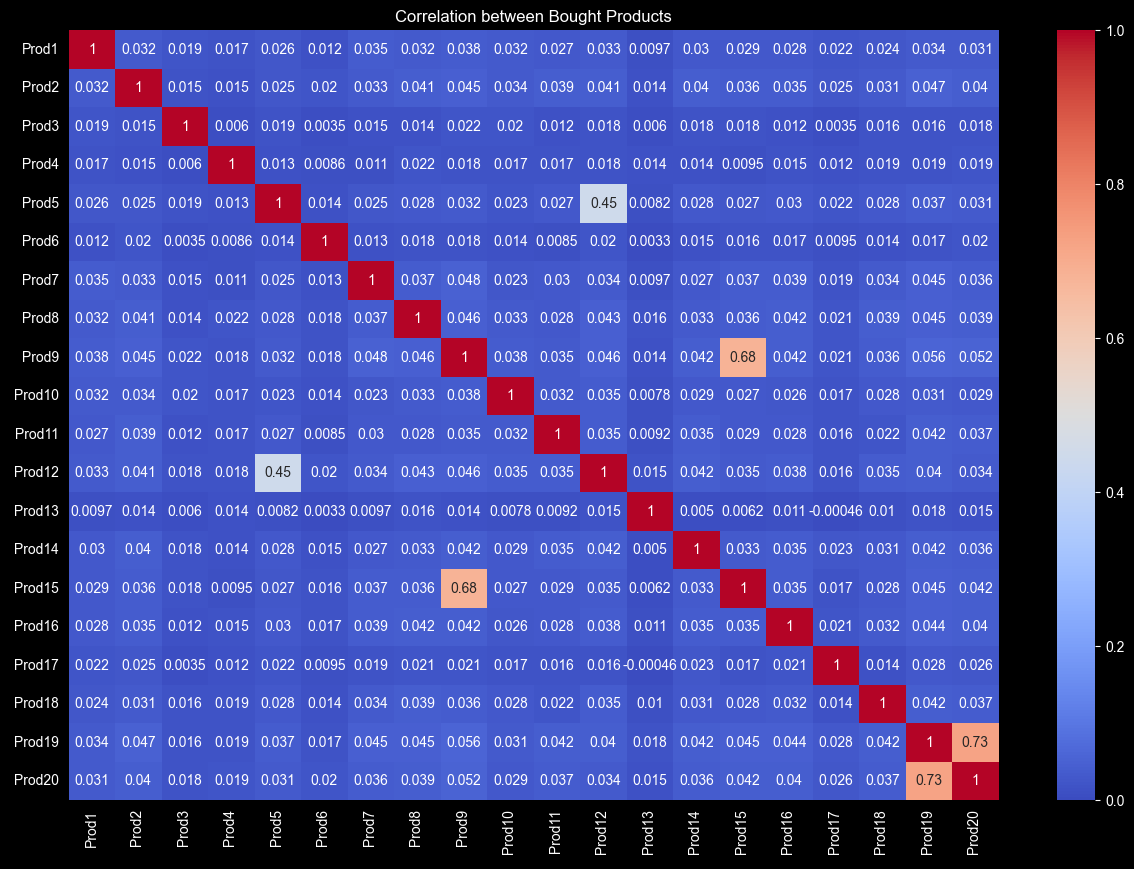

In [141]:
# Heatmap of product groups
plt.figure(figsize=(15, 10))
sns.heatmap(product_groups.drop(columns=['ID']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Bought Products')
plt.show()

The heatmap shows us some hints about the relationships between any two products. We can see 3 pairs of products that have much stronger correlation than the others.

- First pair is Prod12 and Prod5 with the correlation of 0.45
- Second pair is Prod15 and Prod9 with the correlation of 0.68
- Third pair is Prod19 and Prod20 with the correlation of 0.73

These correlations mean that these products are often purchased together. The closer the correlation is to 1, the stronger the relationship between the products. In this case, Prod19 and Prod20 have the strongest relationship, followed by Prod15 and Prod9, and then Prod12 and Prod5.

## Data preparation

For data preparation we will simply check that there is no missing values in the datasets. Otherwise we can assume that the data is in correct format and clean. For the upcoming association rule mining part, we will also need to convert ones and zeros to boolean values.

In [142]:
# Missing values in customer locations dataset
print(f'Missing values in customer locations dataset:\n{customer_locations.isnull().sum()}')
print("---------------------------------------------")

# Missing values in product groups dataset
print(f'Missing values in product groups dataset:\n{product_groups.isnull().sum()}')

Missing values in customer locations dataset:
clientid    0
x           0
y           0
dtype: int64
---------------------------------------------
Missing values in product groups dataset:
ID         0
Prod1      0
 Prod2     0
 Prod3     0
 Prod4     0
 Prod5     0
 Prod6     0
 Prod7     0
 Prod8     0
 Prod9     0
 Prod10    0
 Prod11    0
 Prod12    0
 Prod13    0
 Prod14    0
 Prod15    0
 Prod16    0
 Prod17    0
 Prod18    0
 Prod19    0
 Prod20    0
dtype: int64


In [143]:
# Convert the product groups dataset to boolean values
product_groups = product_groups.drop(columns=['ID'])
product_groups_bool = product_groups.gt(0)

product_groups_bool.head()

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


## Modeling

In the modeling phase we have two tasks.

First will first determine 3 optimal drone hub locations using k-means clustering. We will then create a similar dataframe to the customer locations dataset, but we will add a new column that indicates which cluster each customer location belongs to. We will visualize the clusters by scattering the locations with different colors based on their cluster. To study the performance of the k-means clustering, we will play with the amount of drone hubs and measure the time it takes to compute the clusters. Finally, for the clustering part we will also try to use hierarchical clustering and compare the results with k-means clustering.

Second task is to use association rule mining to find relationships between product groups. We will then study the results and write out the most interesting associations that we find. We will also write some suggestion on how the company could use these associations to improve their business. For example, if we find that certain products are often purchased together, the company could consider bundling those products together or offering discounts for purchasing them together.


In [144]:
hub_amount = 3

### Clustering and hub location analysis

First we will build a k-means clustering model and measure the time it takes to compute 3 clusters.

In [145]:
# using the k-means clustering to find optimal hub locations
kmeans = KMeans(n_clusters=hub_amount, random_state=123)

# starting the timer to measure the time it takes to compute the clusters
start_time = time.time()

# Fit the model to the customer locations data
kmeans.fit(customer_locations[['x', 'y']])

# stopping the timer and calculating the time it took to compute the clusters
end_time = time.time()
elapsed_time = end_time - start_time
print(f'Time taken to compute k-means clustering with {hub_amount} hubs: {elapsed_time:.4f} seconds')


Time taken to compute k-means clustering with 3 hubs: 0.0135 seconds


We will now copy the customer location dataframe and add the cluster labels to the customer locations.

In [146]:
# Copy the customer locations dataframe to a new dataframe
customer_locations_with_clusters = customer_locations.copy()

# Add the cluster labels to the customer locations dataframe
customer_locations_with_clusters['cluster'] = kmeans.labels_

customer_locations_with_clusters.head(10)

,clientid,x,y,cluster
0,1,622.771572,164.857623,2
1,2,416.357298,630.193634,1
2,3,292.735020,567.333231,0
3,4,737.211288,166.225676,2
4,5,540.475375,682.912298,1
5,6,535.469492,318.439661,2
6,7,640.380050,870.833221,1
7,8,235.772075,359.048203,0
8,9,481.896884,661.491838,1
9,10,730.032789,312.177817,2


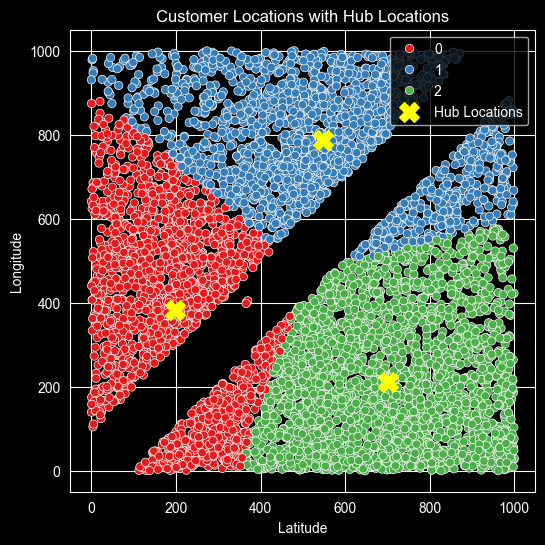

Hub 1 location: (x: 198.54, y: 382.89)
Hub 2 location: (x: 548.01, y: 787.24)
Hub 3 location: (x: 702.21, y: 211.33)


In [147]:
# Get the cluster centers (hub locations)
hub_locations = kmeans.cluster_centers_

# Scatter plot of the optimal hub locations
plt.figure(figsize=(6, 6))
sns.scatterplot(data=customer_locations_with_clusters, x='x', y='y', hue='cluster', palette='Set1')
plt.scatter(hub_locations[:, 0], hub_locations[:, 1], color='yellow', marker='X', s=200, label='Hub Locations')
plt.title('Customer Locations with Hub Locations')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend()
plt.show()

# Print coordinates of the hub locations
for i, hub in enumerate(hub_locations):
    print(f'Hub {i + 1} location: (x: {hub[0]:.2f}, y: {hub[1]:.2f})')


The visualization gives us a clear idea of where the optimal hub locations are based on the customer locations. The yellow X markers represent the hub locations, and the different colors represent the different clusters of customer locations.

Next we wanna try out different amounts of hubs and see how it affects the time it takes to compute the clusters. We will try out 6 and 10 hubs and compare the results with the 3 hubs we already computed.

In [148]:
# Testing clustering with 6 hubs
hub_amount = 6
start_time = time.time()
kmeans_6 = KMeans(n_clusters=hub_amount, random_state=123)
kmeans_6.fit(customer_locations[['x', 'y']])
end_time = time.time()
elapsed_time_6 = end_time - start_time
print(f'Time taken to compute k-means clustering with {hub_amount} hubs: {elapsed_time_6:.4f} seconds')

# Testing clustering with 10 hubs
hub_amount = 10
start_time = time.time()
kmeans_10 = KMeans(n_clusters=hub_amount, random_state=123)
kmeans_10.fit(customer_locations[['x', 'y']])
end_time = time.time()
elapsed_time_10 = end_time - start_time
print(f'Time taken to compute k-means clustering with {hub_amount} hubs: {elapsed_time_10:.4f} seconds')

Time taken to compute k-means clustering with 6 hubs: 0.0122 seconds
Time taken to compute k-means clustering with 10 hubs: 0.0114 seconds


Comparing the results, we can see that as we increase the number of hubs, the time it takes to compute the clusters also increases. This is expected because more clusters require more computations. However, the increase in time is not linear, and it depends on the specific implementation of the k-means algorithm and the size of the dataset.

Finally, we will try to use hierarchical clustering to find optimal hub locations and compare the results with k-means clustering.

In [149]:
# Testing how long it takes to compute hierarchical clustering with 3 hubs
hub_amount = 3
hierarchical = AgglomerativeClustering(n_clusters=hub_amount)

start_time = time.time()
hierarchical.fit(customer_locations[['x', 'y']])
end_time = time.time()
elapsed_time_hierarchical = end_time - start_time

print(f'Time taken to compute hierarchical clustering with {hub_amount} hubs: {elapsed_time_hierarchical:.4f} seconds')

Time taken to compute hierarchical clustering with 3 hubs: 1.0308 seconds


We will talk about the results of the measured times in the next section, but first we will visualize the clusters found by hierarchical clustering.

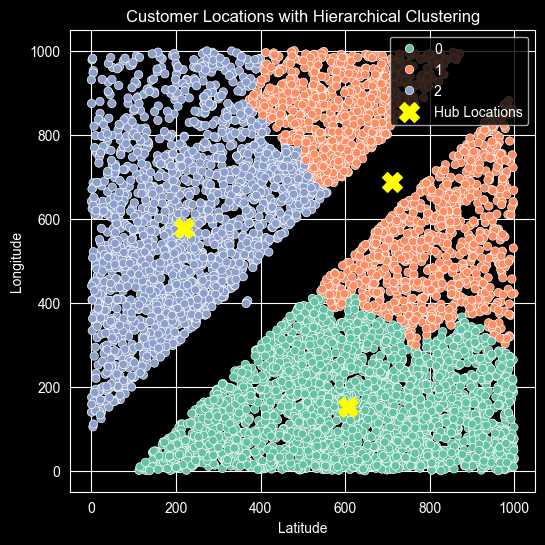

In [150]:
# Get the cluster centers (hub locations) for hierarchical clustering
customer_locations_with_clusters['hierarchical_cluster'] = hierarchical.labels_
hub_locations_hierarchical = customer_locations_with_clusters.groupby('hierarchical_cluster')[['x', 'y']].mean().values

# Scatter plot of the clusters found by hierarchical clustering
customer_locations_with_clusters['hierarchical_cluster'] = hierarchical.labels_
plt.figure(figsize=(6, 6))
sns.scatterplot(data=customer_locations_with_clusters, x='x', y='y', hue='hierarchical_cluster', palette='Set2')
plt.scatter(hub_locations_hierarchical[:, 0], hub_locations_hierarchical[:, 1], color='yellow', marker='X', s=200, label='Hub Locations')
plt.title('Customer Locations with Hierarchical Clustering')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend()
plt.show()

From the visualization we can see that the clusters found by hierarchical clustering are quite different from the clusters found by k-means clustering. One observation we can make from the scatter plot is that the red cluster (1) hub location is placed in the empty area running through the middle of the plot. This could be troublesome, since we dont know what is causing this empty area. If the empty area is caused by some kind of road or river, it could be difficult to build a hub there. The other two hubs are placed in the middle of the blue and green clusters.

### Association rule mining

In this part we will use association rule mining to find relationships between product groups. We will use the apriori algorithm to find frequent itemsets and then generate association rules based on those itemsets. We will then analyze the results and write out the most interesting associations that we find. Finally, we will write some suggestions on how the company could use these associations to improve their business.

In [157]:
# Find the frequent itemsets using the apriori algorithm
frequent_itemsets = apriori(product_groups_bool, min_support=0.1, use_colnames=True)
frequent_itemsets.head()

,support,itemsets
0,0.10998,frozenset({Prod1})
1,0.13098,frozenset({ Prod2})
2,0.10459,frozenset({ Prod5})
3,0.13499,frozenset({ Prod7})
4,0.16179,frozenset({ Prod8})


Association rules

In [158]:
# generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

# sort in descending order of confidence
rules = rules.sort_values(by='confidence', ascending=False)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
3,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
0,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


Lift is a measure of how much more likely the consequent is to be purchased when the antecedent is purchased, compared to when the antecedent is not purchased. A lift value greater than 1 indicates a positive association between the antecedent and the consequent, while a lift value less than 1 indicates a negative association. A lift value of 1 indicates no association between the antecedent and the consequent.

In [159]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=2)

# sort in descending order of lift
rules = rules.sort_values(by='lift', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754
1,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
3,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007


## Evaluation

## Deployment
